# Student Peformance Prediction — Portuguese Language
## Bachelor Thesis | UCI Student Performance Dataset (Cortez & Silva, 2008)
**Dataset:** `../data/student-por.csv`

**Pipeline:**
1. Data Loading & Preprocessing
2. Exploratory Data Analysis
3. Statistical Analysis
4. Machine Learning Models
5. Evaluation (ROC & Precision-Recall Curves)
6. SMOTE — Class Imbalance Mitigation


---
## Setup — Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

LABELS = {
    "age": "Age", "Medu": "Mother's Education", "Fedu": "Father's Education",
    "traveltime": "Travel Time to School", "studytime": "Weekly Study Time",
    "failures": "Past Class Failures", "famrel": "Family Relationship Quality",
    "freetime": "Free Time After School", "goout": "Going Out with Friends",
    "Dalc": "Workday Alcohol Consumption", "Walc": "Weekend Alcohol Consumption",
    "health": "Current Health Status", "absences": "Number of Absences",
    "G1": "First Period Grade", "G2": "Second Period Grade", "G3": "Final Grade (G3)",
    "paid_yes": "Paid Extra Classes", "schoolsup_yes": "Extra School Support",
    "famsup_yes": "Family Educational Support", "activities_yes": "Extracurricular Activities",
    "internet_yes": "Internet Access at Home", "romantic_yes": "In a Romantic Relationship",
    "higher_yes": "Wants Higher Education", "address_U": "Urban Home Address",
    "sex_M": "Sex (Male)", "school_MS": "School (Mousinho da Silveira)",
    "nursery_yes": "Attended Nursery School", "famsize_LE3": "Small Family Size",
    "Pstatus_T": "Parents Living Together",
    "sex":        "Sex",
    "address":    "Home Address Type",
    "famsup":     "Family Educational Support",
    "paid":       "Paid Extra Classes",
    "internet":   "Internet Access at Home",
    "romantic":   "In a Romantic Relationship",
    "schoolsup":  "Extra School Support",
    "activities": "Extracurricular Activities",
    "higher":     "Wants Higher Education",
}
print("Setup complete.")

Setup complete.


---
## Phase 1 — Data Loading & Preprocessing

In [2]:
df_raw = pd.read_csv("../data/student-por.csv", sep=";")
print(f"Dataset shape: {df_raw.shape[0]} students x {df_raw.shape[1]} variables")
df_raw.head()

Dataset shape: 649 students x 33 variables


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
missing = df_raw.isnull().sum().sum()
print(f"Missing values: {'None found' if missing == 0 else missing}")
df_raw.describe().round(2)

Missing values: None found


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00
mean,16.74,2.51,2.31,1.57,1.93,0.22,3.93,3.18,3.18,1.50,2.28,3.54,3.66,11.40,11.57,11.91
std,1.22,1.13,1.10,0.75,0.83,0.59,0.96,1.05,1.18,0.92,1.28,1.45,4.64,2.75,2.91,3.23
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,16.00,2.00,1.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,2.00,0.00,10.00,10.00,10.00
50%,17.00,2.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,2.00,11.00,11.00,12.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,6.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,32.00,19.00,19.00,19.00


In [4]:
df_raw["pass_fail"] = (df_raw["G3"] >= 10).astype(int)
pass_n = df_raw["pass_fail"].sum()
fail_n = len(df_raw) - pass_n
print(f"Pass (G3 >= 10): {pass_n} students  ({pass_n/len(df_raw)*100:.1f}%)")
print(f"Fail (G3 <  10): {fail_n} students  ({fail_n/len(df_raw)*100:.1f}%)")
print(f"Naive baseline (always predict Pass): {pass_n/len(df_raw)*100:.1f}%")


Pass (G3 >= 10): 549 students  (84.6%)
Fail (G3 <  10): 100 students  (15.4%)
Naive baseline (always predict Pass): 84.6%


In [5]:
categorical_cols = df_raw.select_dtypes(include="object").columns.tolist()
df_encoded = pd.get_dummies(df_raw, columns=categorical_cols, drop_first=True)
print(f"Shape before encoding: {df_raw.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")

exclude_cols = ["G3", "pass_fail", "G1", "G2"]
feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]
print(f"Features available: {len(feature_cols)}")

X     = df_encoded[feature_cols]
y_reg = df_encoded["G3"]
y_clf = df_encoded["pass_fail"]

df_encoded.to_csv("../data/student_por_preprocessed.csv", index=False)
print("Saved: ../data/student_por_preprocessed.csv")

Shape before encoding: (649, 34)
Shape after encoding:  (649, 43)
Features available: 39
Saved: ../data/student_por_preprocessed.csv


---
## Phase 2 — Exploratory Data Analysis (EDA)

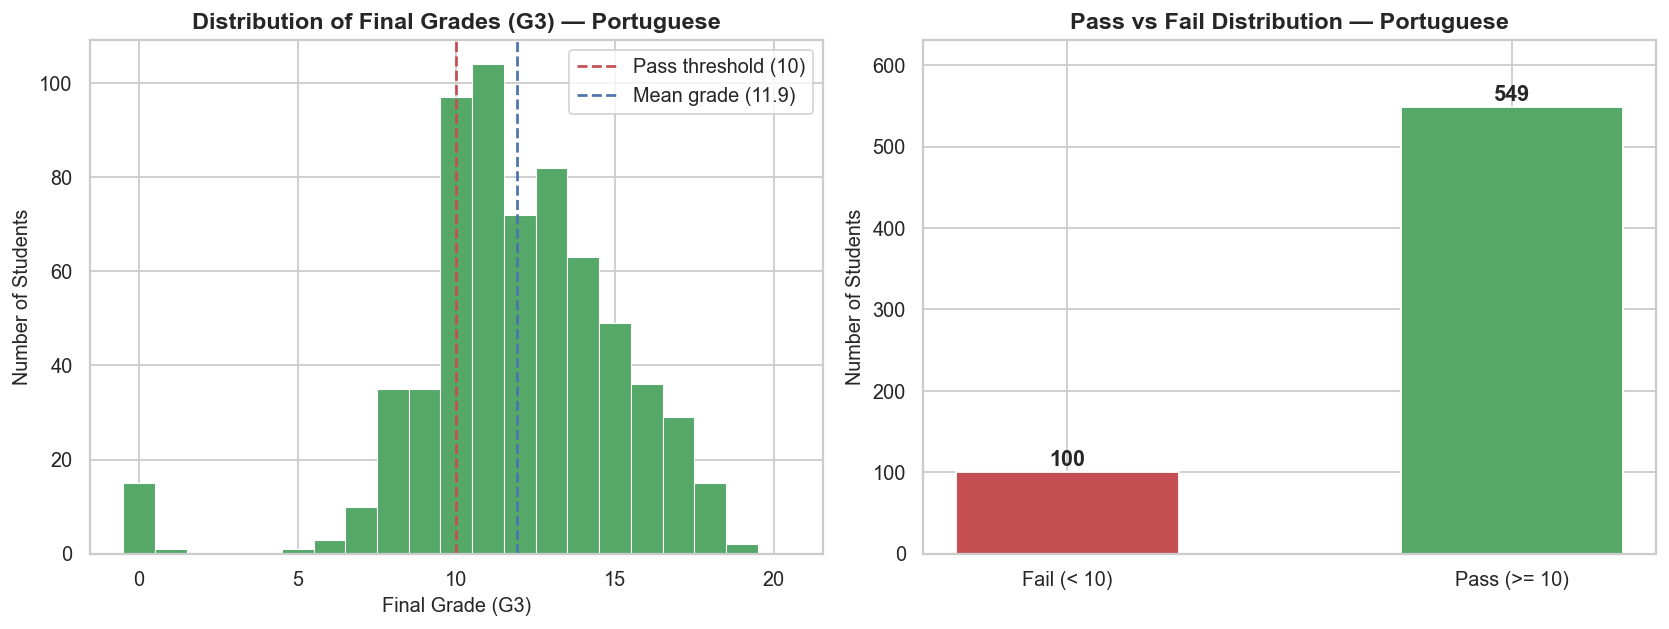

Mean: 11.91  Std: 3.23  Pass rate: 84.6%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grade distribution
ax = axes[0]
ax.hist(df_raw["G3"], bins=21, range=(-0.5, 20.5),
        color="#55A868", edgecolor="white", linewidth=0.6)
ax.axvline(x=10, color="#C44E52", linestyle="--", linewidth=1.5,
           label="Pass threshold (10)")
ax.axvline(x=df_raw["G3"].mean(), color="#4C72B0", linestyle="--", linewidth=1.5,
           label=f"Mean grade ({df_raw['G3'].mean():.1f})")
ax.set_title("Distribution of Final Grades (G3) — Portuguese",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Final Grade (G3)", fontsize=11)
ax.set_ylabel("Number of Students", fontsize=11)
ax.legend()

# Pass/Fail
counts = df_raw["pass_fail"].value_counts().sort_index()
bars = axes[1].bar(["Fail (< 10)", "Pass (>= 10)"], counts.values,
                   color=["#C44E52", "#55A868"], edgecolor="white", width=0.5)
for bar, count in zip(bars, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 str(count), ha="center", va="bottom", fontsize=12, fontweight="bold")
axes[1].set_title("Pass vs Fail Distribution — Portuguese",
                  fontsize=13, fontweight="bold")
axes[1].set_ylabel("Number of Students", fontsize=11)
axes[1].set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.savefig("../plots/por_plot1_grade_dist_passfail.png")
plt.show()
print(f"Mean: {df_raw['G3'].mean():.2f}  Std: {df_raw['G3'].std():.2f}  Pass rate: {df_raw['pass_fail'].mean()*100:.1f}%")

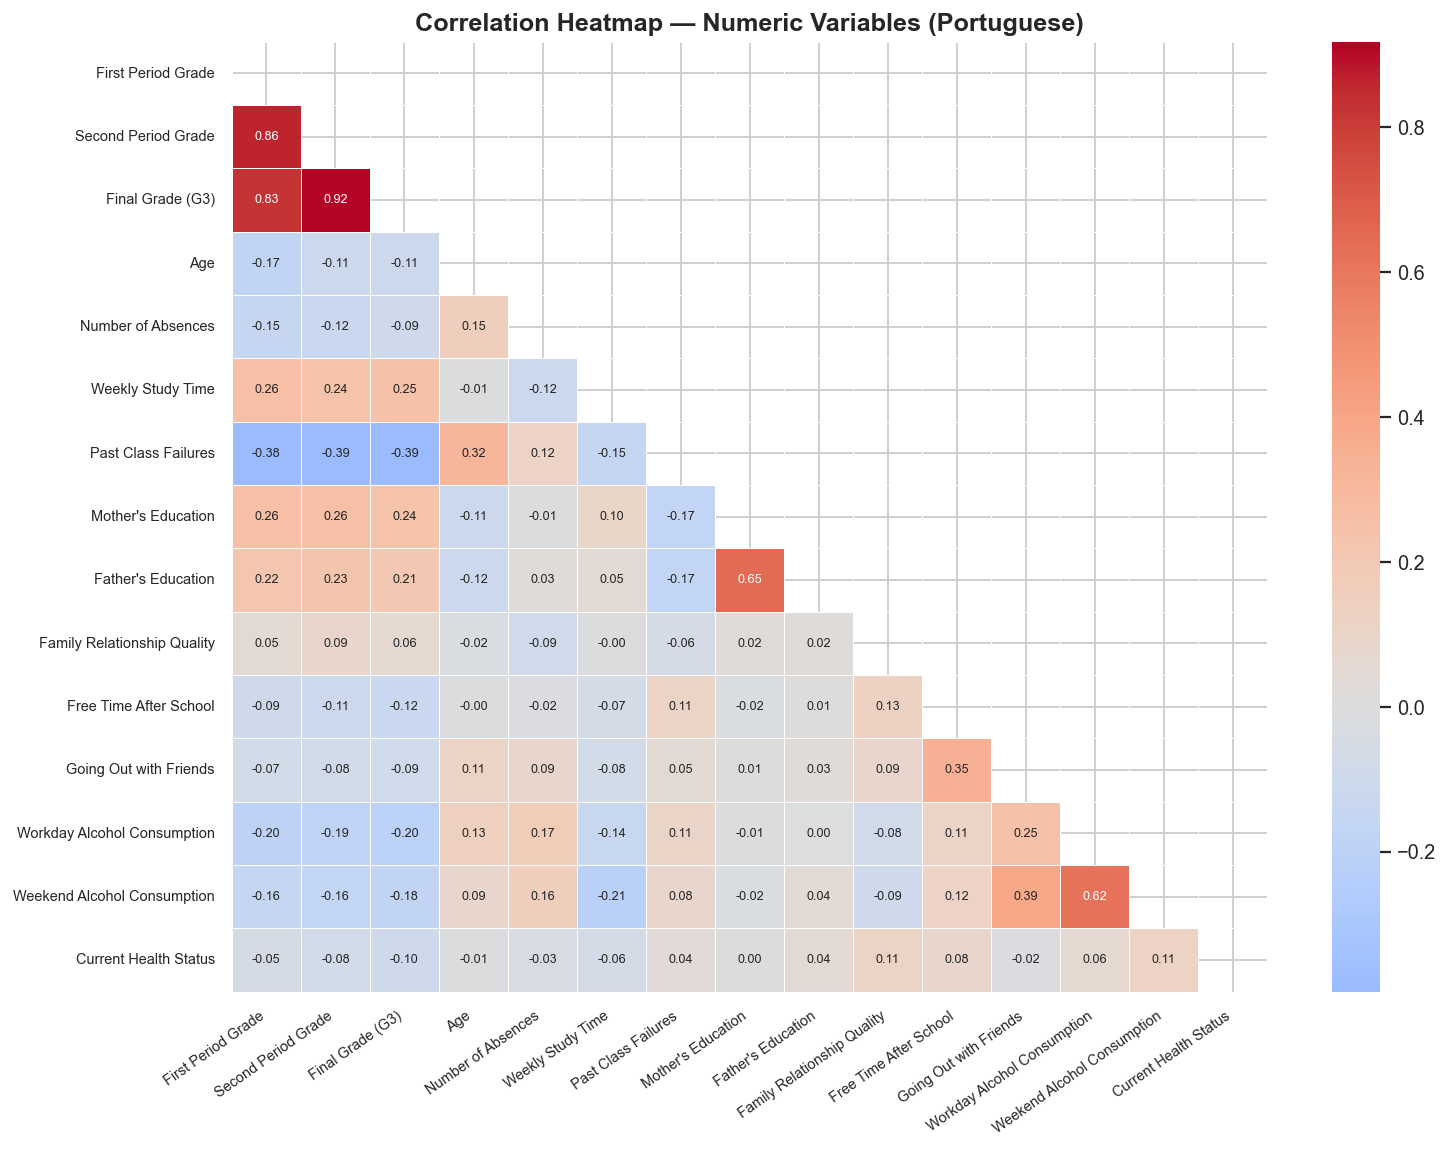

In [7]:
# Correlation Heatmap
numeric_cols = ["G1","G2","G3","age","absences","studytime","failures",
                "Medu","Fedu","famrel","freetime","goout","Dalc","Walc","health"]
df_heatmap = df_raw[numeric_cols].copy()
df_heatmap.rename(columns=LABELS, inplace=True)
corr_matrix = df_heatmap.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlation Heatmap — Numeric Variables (Portuguese)",
             fontsize=14, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("../plots/por_plot5_correlation_heatmap.png")
plt.show()

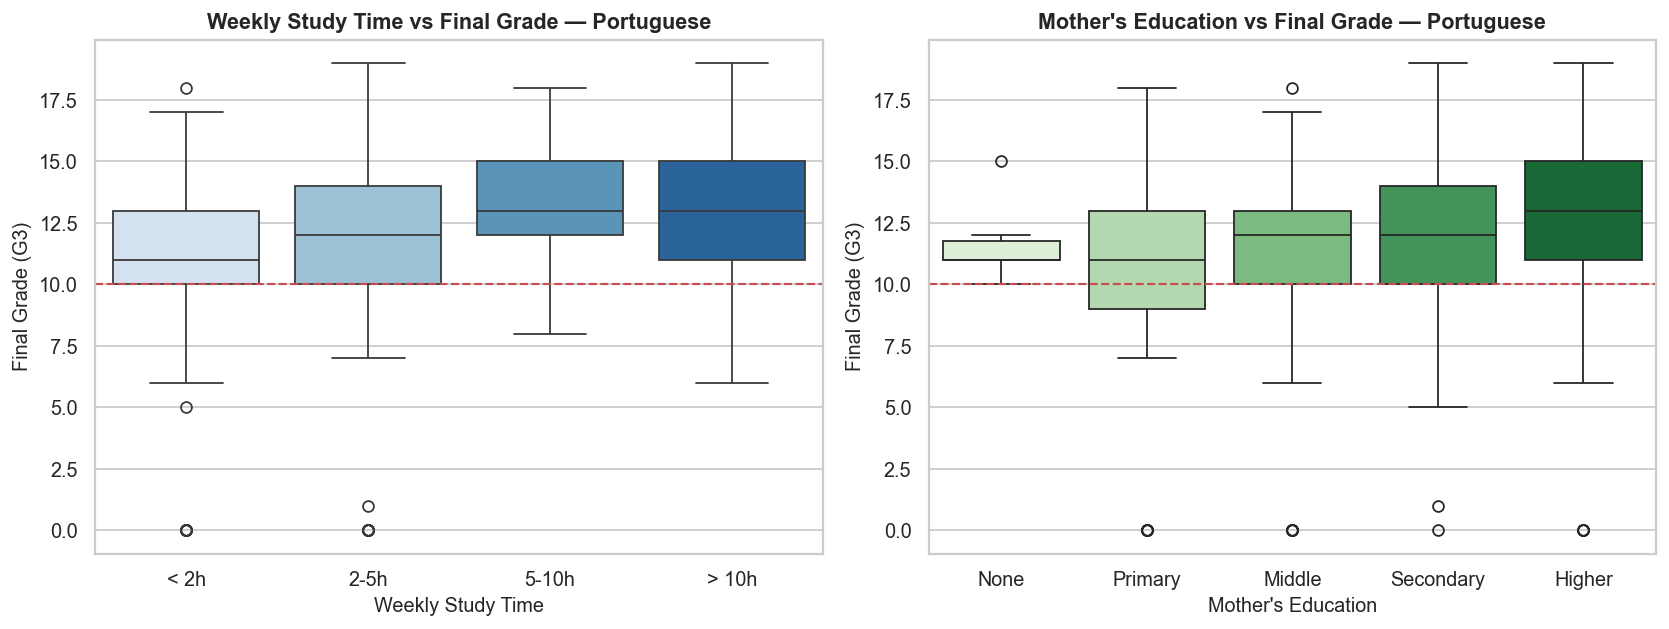

Study Time vs G3: r = 0.2498  p = 0.0000


In [8]:
# Study Time vs Grade | Mother's Education vs Grade
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

studytime_labels = {1: "< 2h", 2: "2-5h", 3: "5-10h", 4: "> 10h"}
df_raw["studytime_label"] = df_raw["studytime"].map(studytime_labels)
order = ["< 2h", "2-5h", "5-10h", "> 10h"]
sns.boxplot(data=df_raw, x="studytime_label", y="G3", order=order,
            hue="studytime_label", hue_order=order,
            palette="Blues", legend=False, ax=axes[0])
axes[0].axhline(y=10, color="#C44E52", linestyle="--", linewidth=1.2)
axes[0].set_title("Weekly Study Time vs Final Grade — Portuguese",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Weekly Study Time", fontsize=11)
axes[0].set_ylabel("Final Grade (G3)", fontsize=11)

medu_labels = {0:"None",1:"Primary",2:"Middle",3:"Secondary",4:"Higher"}
df_raw["Medu_label"] = df_raw["Medu"].map(medu_labels)
medu_order = ["None","Primary","Middle","Secondary","Higher"]
sns.boxplot(data=df_raw, x="Medu_label", y="G3", order=medu_order,
            hue="Medu_label", hue_order=medu_order,
            palette="Greens", legend=False, ax=axes[1])
axes[1].axhline(y=10, color="#C44E52", linestyle="--", linewidth=1.2)
axes[1].set_title("Mother's Education vs Final Grade — Portuguese",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Mother's Education", fontsize=11)
axes[1].set_ylabel("Final Grade (G3)", fontsize=11)

plt.tight_layout()
plt.savefig("../plots/por_plot3_studytime_medu.png")
plt.show()

r_st, p_st = stats.pearsonr(df_raw["studytime"], df_raw["G3"])
print(f"Study Time vs G3: r = {r_st:.4f}  p = {p_st:.4f}")

---
## Phase 3 — Statistical Analysis

In [9]:
w_stat, p_norm = stats.shapiro(df_raw["G3"])
print(f"Shapiro-Wilk: W = {w_stat:.4f},  p = {p_norm:.6f}")
print(f"G3 is {'NOT ' if p_norm < 0.05 else ''}normally distributed")
print("=> Mann-Whitney U test reported alongside t-test.")

Shapiro-Wilk: W = 0.9260,  p = 0.000000
G3 is NOT normally distributed
=> Mann-Whitney U test reported alongside t-test.


In [10]:
numeric_vars = ["age","Medu","Fedu","traveltime","studytime","failures",
                "famrel","freetime","goout","Dalc","Walc","health","absences"]

print(f"{'Variable':<30} {'r':>8} {'p-value':>12} {'Significant':>14} {'Strength':>12}")
print("-" * 65)

correlation_results = []
for var in numeric_vars:
    r, p = stats.pearsonr(df_raw[var], df_raw["G3"])
    sig = "Yes ***" if p < 0.001 else ("Yes **" if p < 0.01 else
          ("Yes *" if p < 0.05 else "No"))
    abs_r = abs(r)
    strength = "Strong" if abs_r >= 0.50 else ("Moderate" if abs_r >= 0.30 else
               ("Weak" if abs_r >= 0.10 else "Negligible"))
    label = LABELS.get(var, var)
    print(f"{label:<30} {r:>8.4f} {p:>12.4f} {sig:>14} {strength:>12}")
    correlation_results.append({
        "Variable": label, "r": round(r,4), "p-value": round(p,4),
        "Significant": "Yes" if p < 0.05 else "No",
        "Strength": strength, "Direction": "positive" if r > 0 else "negative"
    })

corr_df = pd.DataFrame(correlation_results)
corr_df.to_csv("../results/por_results_correlations.csv", index=False)
print("\nSaved: ../results/por_results_correlations.csv")
print("\nSignificance: * p<0.05  ** p<0.01  *** p<0.001")

Variable                              r      p-value    Significant     Strength
-----------------------------------------------------------------
Age                             -0.1065       0.0066         Yes **         Weak
Mother's Education               0.2402       0.0000        Yes ***         Weak
Father's Education               0.2118       0.0000        Yes ***         Weak
Travel Time to School           -0.1272       0.0012         Yes **         Weak
Weekly Study Time                0.2498       0.0000        Yes ***         Weak
Past Class Failures             -0.3933       0.0000        Yes ***     Moderate
Family Relationship Quality      0.0634       0.1068             No   Negligible
Free Time After School          -0.1227       0.0017         Yes **         Weak
Going Out with Friends          -0.0876       0.0256          Yes *   Negligible
Workday Alcohol Consumption     -0.2047       0.0000        Yes ***         Weak
Weekend Alcohol Consumption     -0.1766    

In [11]:
def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled = np.sqrt(((n1-1)*g1.std()**2 + (n2-1)*g2.std()**2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled if pooled != 0 else 0

def interpret_d(d):
    a = abs(d)
    return "Large" if a >= 0.80 else ("Medium" if a >= 0.50 else
           ("Small" if a >= 0.20 else "Negligible"))

binary_tests = [
    ("sex",        "F",   "M",   "Female",              "Male"),
    ("address",    "U",   "R",   "Urban",               "Rural"),
    ("famsup",     "yes", "no",  "Family support",      "No family support"),
    ("paid",       "yes", "no",  "Paid tutoring",       "No tutoring"),
    ("internet",   "yes", "no",  "Internet at home",    "No internet"),
    ("romantic",   "yes", "no",  "In a relationship",   "Not in relationship"),
    ("schoolsup",  "yes", "no",  "School support",      "No school support"),
    ("activities", "yes", "no",  "Extracurricular",     "No activities"),
    ("higher",     "yes", "no",  "Wants higher edu.",   "Does not"),
]

hypothesis_results = []
for var, v1, v2, l1, l2 in binary_tests:
    g1 = df_raw[df_raw[var] == v1]["G3"]
    g2 = df_raw[df_raw[var] == v2]["G3"]
    _, t_p  = stats.ttest_ind(g1, g2)
    _, mw_p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    d       = cohens_d(g1, g2)
    print(f"{l1} vs {l2}:")
    print(f"  Mean G3: {g1.mean():.2f} vs {g2.mean():.2f}  |  "
          f"t p={t_p:.4f}  MW p={mw_p:.4f}  d={d:.3f} ({interpret_d(d)})  "
          f"{'SIG *' if t_p < 0.05 else ''}")
    hypothesis_results.append({
        "Variable": LABELS.get(var,var), "Group 1": l1, "Group 2": l2,
        "Mean G3 (Group 1)": round(g1.mean(),2), "Mean G3 (Group 2)": round(g2.mean(),2),
        "t p-value": round(t_p,4), "Mann-Whitney p": round(mw_p,4),
        "Cohen's d": round(d,3), "Effect Size": interpret_d(d),
        "Significant": "Yes" if t_p < 0.05 else "No"
    })

pd.DataFrame(hypothesis_results).to_csv("../results/por_results_hypothesis_tests.csv", index=False)
print("\nSaved: ../results/por_results_hypothesis_tests.csv")

Female vs Male:
  Mean G3: 12.25 vs 11.41  |  t p=0.0010  MW p=0.0006  d=0.264 (Small)  SIG *
Urban vs Rural:
  Mean G3: 12.26 vs 11.09  |  t p=0.0000  MW p=0.0000  d=0.369 (Small)  SIG *
Family support vs No family support:
  Mean G3: 12.06 vs 11.67  |  t p=0.1319  MW p=0.4549  d=0.122 (Negligible)  
Paid tutoring vs No tutoring:
  Mean G3: 11.21 vs 11.95  |  t p=0.1624  MW p=0.1494  d=-0.231 (Small)  
Internet at home vs No internet:
  Mean G3: 12.17 vs 11.03  |  t p=0.0001  MW p=0.0001  d=0.359 (Small)  SIG *
In a relationship vs Not in relationship:
  Mean G3: 11.52 vs 12.13  |  t p=0.0210  MW p=0.0672  d=-0.188 (Negligible)  SIG *
School support vs No school support:
  Mean G3: 11.28 vs 11.98  |  t p=0.0910  MW p=0.0261  d=-0.217 (Small)  
Extracurricular vs No activities:
  Mean G3: 12.10 vs 11.72  |  t p=0.1281  MW p=0.0369  d=0.120 (Negligible)  
Wants higher edu. vs Does not:
  Mean G3: 12.28 vs 8.80  |  t p=0.0000  MW p=0.0000  d=1.141 (Large)  SIG *

Saved: ../results/por_re

---
## Phase 4 — Machine Learning Models

In [12]:
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)
_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}  |  Test samples: {len(X_test)}")
print(f"Test — Pass: {(y_clf_test==1).sum()}  |  Fail: {(y_clf_test==0).sum()}")
print(f"\nCaution: only {(y_clf_test==0).sum()} failing students in test set.")
print("Fail class metrics will be statistically unstable.")

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Training samples: 519  |  Test samples: 130
Test — Pass: 115  |  Fail: 15

Caution: only 15 failing students in test set.
Fail class metrics will be statistically unstable.


In [13]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_reg_train)
y_pred_lr = lr.predict(X_test)

r2   = r2_score(y_reg_test, y_pred_lr)
mae  = mean_absolute_error(y_reg_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_lr))
cv_r2 = cross_val_score(lr, X, y_reg, cv=5, scoring="r2")

print("MODEL 1: Linear Regression")
print(f"  R2:             {r2:.4f}  (Math: 0.1415)")
print(f"  MAE:            {mae:.4f}  grade points  (Math: 3.3953)")
print(f"  RMSE:           {rmse:.4f}  (Math: 4.1957)")
print(f"  CV R2 (5-fold): {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}")
print()
print("Lower MAE partly explained by lower grade variance (std=3.23 vs 4.58 in Math).")

MODEL 1: Linear Regression
  R2:             0.1602  (Math: 0.1415)
  MAE:            2.1564  grade points  (Math: 3.3953)
  RMSE:           2.8618  (Math: 4.1957)
  CV R2 (5-fold): 0.1639 +/- 0.1081

Lower MAE partly explained by lower grade variance (std=3.23 vs 4.58 in Math).


In [14]:
# Classification models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf      = RandomForestClassifier(n_estimators=100, random_state=42)
nn      = MLPClassifier(hidden_layer_sizes=(32,), activation="relu",
                        max_iter=2000, early_stopping=True,
                        validation_fraction=0.1, n_iter_no_change=20,
                        random_state=42)

log_reg.fit(X_train_scaled, y_clf_train)
rf.fit(X_train, y_clf_train)
nn.fit(X_train_scaled, y_clf_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf  = rf.predict(X_test)
y_pred_nn  = nn.predict(X_test_scaled)

print(f"Naive baseline (always predict Pass): {y_clf.mean()*100:.1f}%")
print()
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 62)
for name, yp in [("Logistic Regression", y_pred_log),
                  ("Random Forest",       y_pred_rf),
                  ("Neural Network",      y_pred_nn)]:
    print(f"{name:<22} "
          f"{accuracy_score(y_clf_test, yp):>10.4f} "
          f"{precision_score(y_clf_test, yp, zero_division=0):>10.4f} "
          f"{recall_score(y_clf_test, yp, zero_division=0):>8.4f} "
          f"{f1_score(y_clf_test, yp, zero_division=0):>8.4f}")
print()
print("Note: Random Forest wins in Portuguese (more data = more complex model benefits).")

Naive baseline (always predict Pass): 84.6%

Model                    Accuracy  Precision   Recall       F1
--------------------------------------------------------------
Logistic Regression        0.8769     0.9231   0.9391   0.9310
Random Forest              0.8846     0.8906   0.9913   0.9383
Neural Network             0.8077     0.8947   0.8870   0.8908

Note: Random Forest wins in Portuguese (more data = more complex model benefits).


In [15]:
# Classification Reports
for name, yp in [("Logistic Regression", y_pred_log),
                  ("Random Forest",       y_pred_rf),
                  ("Neural Network",      y_pred_nn)]:
    print(f"--- {name} ---")
    print(classification_report(y_clf_test, yp,
                                 target_names=["Fail", "Pass"], zero_division=0))

--- Logistic Regression ---
              precision    recall  f1-score   support

        Fail       0.46      0.40      0.43        15
        Pass       0.92      0.94      0.93       115

    accuracy                           0.88       130
   macro avg       0.69      0.67      0.68       130
weighted avg       0.87      0.88      0.87       130

--- Random Forest ---
              precision    recall  f1-score   support

        Fail       0.50      0.07      0.12        15
        Pass       0.89      0.99      0.94       115

    accuracy                           0.88       130
   macro avg       0.70      0.53      0.53       130
weighted avg       0.85      0.88      0.84       130

--- Neural Network ---
              precision    recall  f1-score   support

        Fail       0.19      0.20      0.19        15
        Pass       0.89      0.89      0.89       115

    accuracy                           0.81       130
   macro avg       0.54      0.54      0.54       130
w

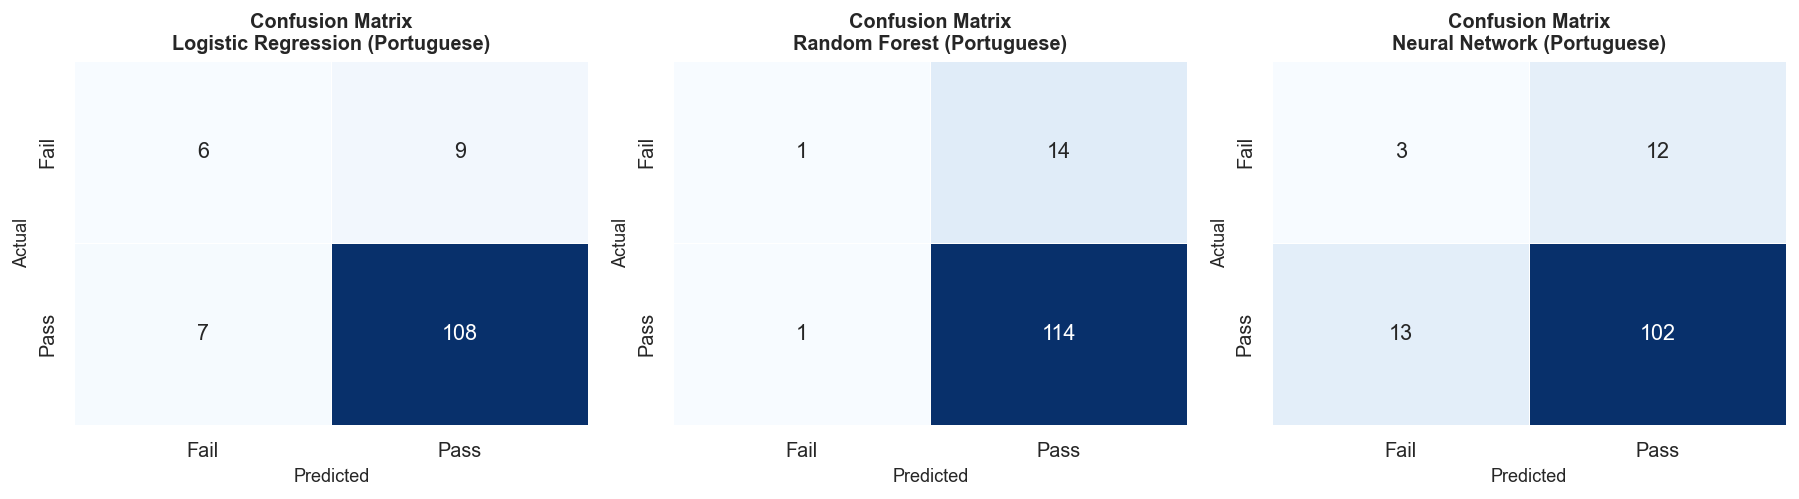

Total failing students in test set: 15
  Logistic Regression: caught 6/15  (Fail Recall = 0.4000)
  Random Forest: caught 1/15  (Fail Recall = 0.0667)
  Neural Network: caught 3/15  (Fail Recall = 0.2000)


In [16]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, y_pred, title in zip(
    axes,
    [y_pred_log, y_pred_rf, y_pred_nn],
    ["Logistic Regression", "Random Forest", "Neural Network"]
):
    cm = confusion_matrix(y_clf_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Fail","Pass"], yticklabels=["Fail","Pass"],
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(f"Confusion Matrix\n{title} (Portuguese)",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)
plt.tight_layout()
plt.savefig("../plots/por_plot8_confusion_matrices.png")
plt.show()

total_fail = (y_clf_test==0).sum()
print(f"Total failing students in test set: {total_fail}")
for name, yp in [("Logistic Regression", y_pred_log),
                  ("Random Forest",       y_pred_rf),
                  ("Neural Network",      y_pred_nn)]:
    cm = confusion_matrix(y_clf_test, yp)
    tn, fp, fn, tp = cm.ravel()
    fr = tn/(tn+fp) if (tn+fp)>0 else 0
    print(f"  {name}: caught {tn}/{total_fail}  (Fail Recall = {fr:.4f})")

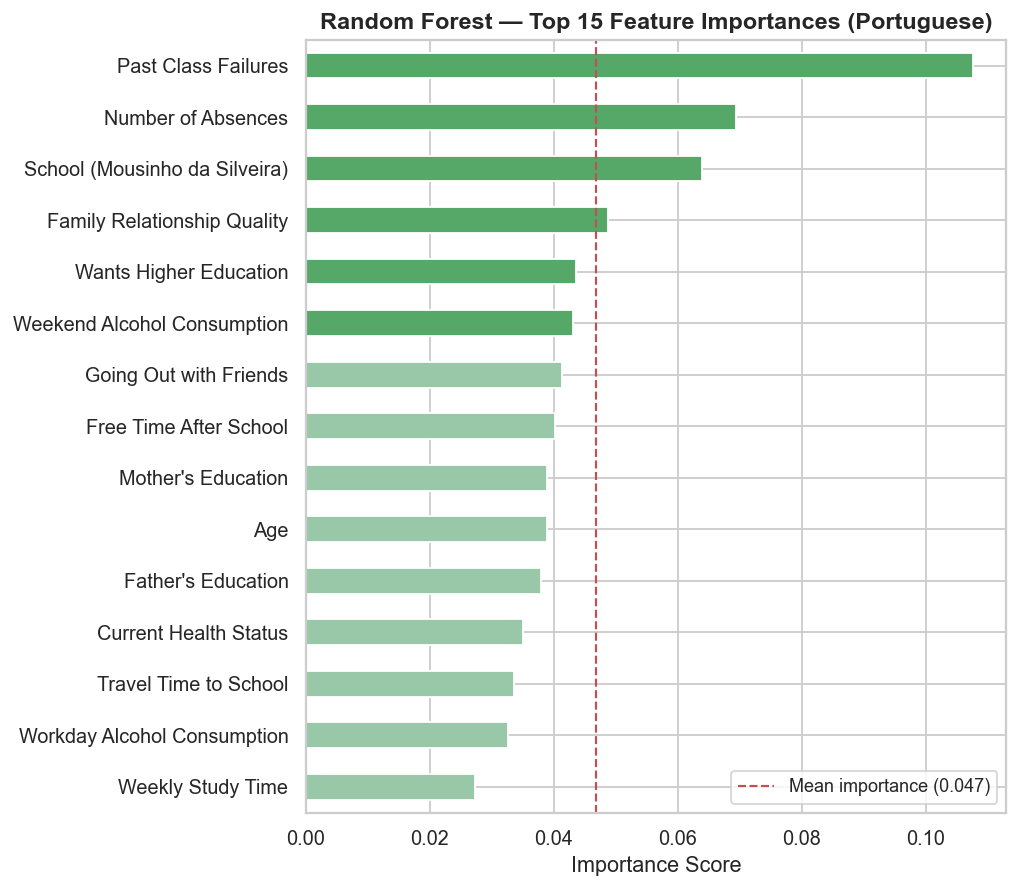

Top 5 features:
  1. Past Class Failures: 0.1076
  2. Number of Absences: 0.0695
  3. School (Mousinho da Silveira): 0.0640
  4. Family Relationship Quality: 0.0487
  5. Wants Higher Education: 0.0436

Note: Past Class Failures tops Portuguese (vs Number of Absences in Mathematics).


In [17]:
# Feature Importances
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.index = [LABELS.get(col, col) for col in importances.index]
top15 = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#55A868" if v >= top15.quantile(0.6) else "#99C8A9" for v in top15.values]
top15.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(x=top15.mean(), color="#C44E52", linestyle="--", linewidth=1.2,
           label=f"Mean importance ({top15.mean():.3f})")
ax.set_title("Random Forest — Top 15 Feature Importances (Portuguese)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../plots/por_plot9_feature_importances.png")
plt.show()

print("Top 5 features:")
for i, (feat, score) in enumerate(importances.sort_values(ascending=False).head(5).items(), 1):
    print(f"  {i}. {feat}: {score:.4f}")
print()
print("Note: Past Class Failures tops Portuguese (vs Number of Absences in Mathematics).")

---
## Phase 5 — Evaluation: ROC & Precision-Recall Curves

In [18]:
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_r2  = cross_val_score(lr, X, y_reg, cv=5, scoring="r2")
cv_log = cross_val_score(log_reg, X_train_scaled, y_clf_train, cv=skf, scoring="f1")
cv_rf  = cross_val_score(rf, X, y_clf, cv=skf, scoring="f1")
cv_nn  = cross_val_score(nn, X_train_scaled, y_clf_train, cv=skf, scoring="f1")

m_log = {"accuracy": accuracy_score(y_clf_test, y_pred_log),
         "f1": f1_score(y_clf_test, y_pred_log, zero_division=0)}
m_rf  = {"accuracy": accuracy_score(y_clf_test, y_pred_rf),
         "f1": f1_score(y_clf_test, y_pred_rf, zero_division=0)}
m_nn  = {"accuracy": accuracy_score(y_clf_test, y_pred_nn),
         "f1": f1_score(y_clf_test, y_pred_nn, zero_division=0)}

print(f"{'Metric':<28} {'Linear Reg':>12} {'Logistic Reg':>14} {'Random Forest':>14} {'Neural Net':>11}")
print("-" * 82)
print(f"{'R2':<28} {r2:>12.4f} {'--':>14} {'--':>14} {'--':>11}")
print(f"{'MAE':<28} {mae:>12.4f} {'--':>14} {'--':>14} {'--':>11}")
print(f"{'Accuracy':<28} {'--':>12} {m_log['accuracy']:>14.4f} {m_rf['accuracy']:>14.4f} {m_nn['accuracy']:>11.4f}")
print(f"{'F1 Score (Pass)':<28} {'--':>12} {m_log['f1']:>14.4f} {m_rf['f1']:>14.4f} {m_nn['f1']:>11.4f}")
print(f"{'CV Score (5-fold F1)':<28} {cv_r2.mean():>12.4f} {cv_log.mean():>14.4f} {cv_rf.mean():>14.4f} {cv_nn.mean():>11.4f}")
print(f"{'CV Std Dev':<28} {cv_r2.std():>12.4f} {cv_log.std():>14.4f} {cv_rf.std():>14.4f} {cv_nn.std():>11.4f}")
print()
print(f"Neural Network CV std: {cv_nn.std():.4f} (was 0.0842 in Mathematics)")
print("=> Same architecture becomes much more stable with more training data (519 vs 316).")

Metric                         Linear Reg   Logistic Reg  Random Forest  Neural Net
----------------------------------------------------------------------------------
R2                                 0.1602             --             --          --
MAE                                2.1564             --             --          --
Accuracy                               --         0.8769         0.8846      0.8077
F1 Score (Pass)                        --         0.9310         0.9383      0.8908
CV Score (5-fold F1)               0.1639         0.9013         0.9209      0.8874
CV Std Dev                         0.1081         0.0235         0.0055      0.0112

Neural Network CV std: 0.0112 (was 0.0842 in Mathematics)
=> Same architecture becomes much more stable with more training data (519 vs 316).


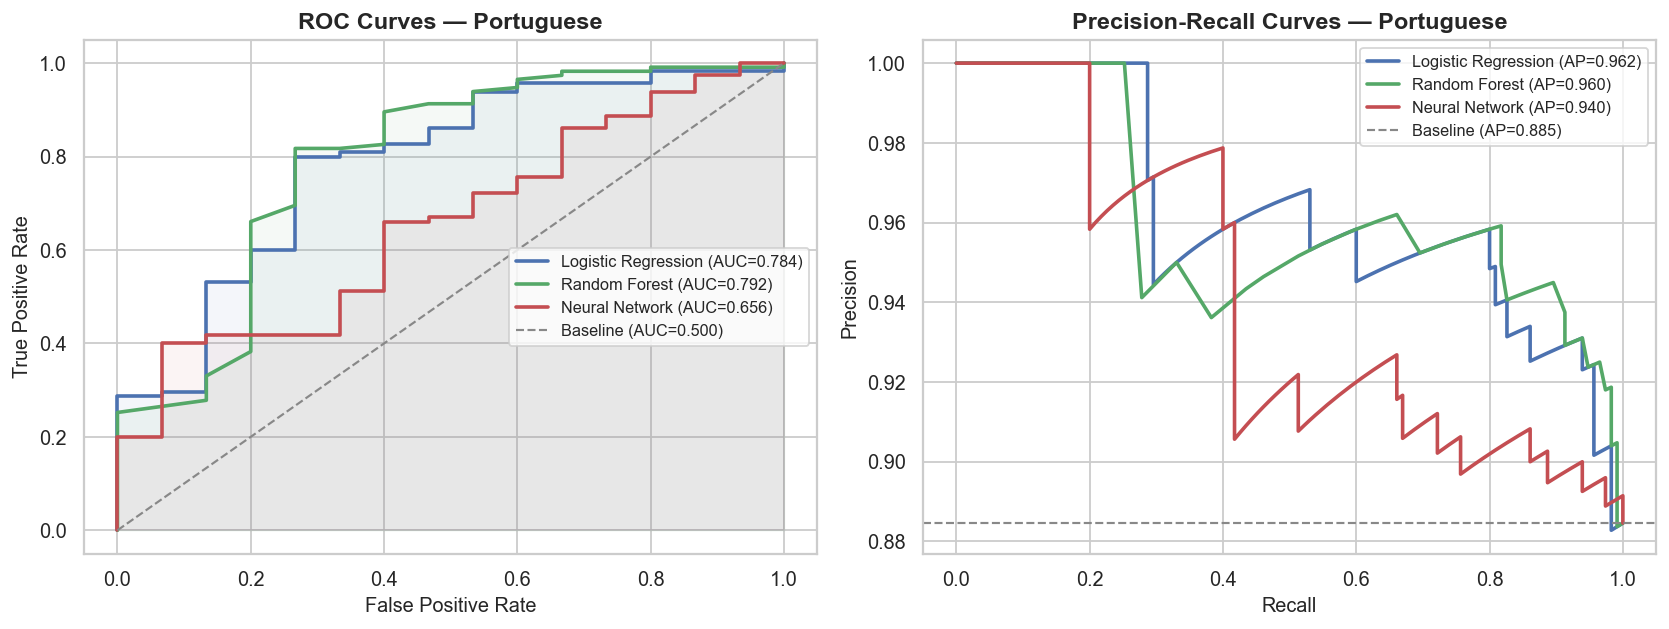

In [19]:
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_rf  = rf.predict_proba(X_test)[:, 1]
y_prob_nn  = nn.predict_proba(X_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for prob, label, color in [
    (y_prob_log, "Logistic Regression", "#4C72B0"),
    (y_prob_rf,  "Random Forest",       "#55A868"),
    (y_prob_nn,  "Neural Network",      "#C44E52"),
]:
    fpr, tpr, _ = roc_curve(y_clf_test, prob)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{label} (AUC={auc_val:.3f})")
    ax.fill_between(fpr, tpr, alpha=0.06, color=color)
ax.plot([0,1],[0,1], color="#888", linestyle="--", linewidth=1.2,
        label="Baseline (AUC=0.500)")
ax.set_title("ROC Curves — Portuguese", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
baseline_pr = y_clf_test.mean()
for prob, label, color in [
    (y_prob_log, "Logistic Regression", "#4C72B0"),
    (y_prob_rf,  "Random Forest",       "#55A868"),
    (y_prob_nn,  "Neural Network",      "#C44E52"),
]:
    prec_c, rec_c, _ = precision_recall_curve(y_clf_test, prob)
    ap = average_precision_score(y_clf_test, prob)
    ax.plot(rec_c, prec_c, color=color, linewidth=2,
            label=f"{label} (AP={ap:.3f})")
ax.axhline(y=baseline_pr, color="#888", linestyle="--", linewidth=1.2,
           label=f"Baseline (AP={baseline_pr:.3f})")
ax.set_title("Precision-Recall Curves — Portuguese", fontsize=13, fontweight="bold")
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../plots/por_plot11_roc_pr_curves.png")
plt.show()

In [20]:
report = pd.DataFrame([
    {"Model": "Linear Regression",   "Task": "Regression",
     "R²": round(r2,4), "MAE": round(mae,4), "RMSE": round(rmse,4),
     "Accuracy": "--", "Precision": "--", "Recall": "--", "F1": "--",
     "CV Mean": round(cv_r2.mean(),4), "CV Std": round(cv_r2.std(),4), "AUC-ROC": "--"},
    {"Model": "Logistic Regression", "Task": "Classification",
     "R²": "--", "MAE": "--", "RMSE": "--",
     "Accuracy": round(m_log["accuracy"],4),
     "Precision": round(precision_score(y_clf_test, y_pred_log, zero_division=0),4),
     "Recall":    round(recall_score(y_clf_test, y_pred_log, zero_division=0),4),
     "F1": round(m_log["f1"],4),
     "CV Mean": round(cv_log.mean(),4), "CV Std": round(cv_log.std(),4),
     "AUC-ROC": round(auc(*roc_curve(y_clf_test,y_prob_log)[:2]),4)},
    {"Model": "Random Forest",       "Task": "Classification",
     "R²": "--", "MAE": "--", "RMSE": "--",
     "Accuracy": round(m_rf["accuracy"],4),
     "Precision": round(precision_score(y_clf_test, y_pred_rf, zero_division=0),4),
     "Recall":    round(recall_score(y_clf_test, y_pred_rf, zero_division=0),4),
     "F1": round(m_rf["f1"],4),
     "CV Mean": round(cv_rf.mean(),4), "CV Std": round(cv_rf.std(),4),
     "AUC-ROC": round(auc(*roc_curve(y_clf_test,y_prob_rf)[:2]),4)},
    {"Model": "Neural Network",      "Task": "Classification",
     "R²": "--", "MAE": "--", "RMSE": "--",
     "Accuracy": round(m_nn["accuracy"],4),
     "Precision": round(precision_score(y_clf_test, y_pred_nn, zero_division=0),4),
     "Recall":    round(recall_score(y_clf_test, y_pred_nn, zero_division=0),4),
     "F1": round(m_nn["f1"],4),
     "CV Mean": round(cv_nn.mean(),4), "CV Std": round(cv_nn.std(),4),
     "AUC-ROC": round(auc(*roc_curve(y_clf_test,y_prob_nn)[:2]),4)},
])
report.to_csv("../results/por_results_final_report.csv", index=False)
print("Saved: ../results/por_results_final_report.csv")
print()
print(report.to_string(index=False))

Saved: ../results/por_results_final_report.csv

              Model           Task      R²     MAE    RMSE Accuracy Precision  Recall      F1  CV Mean  CV Std AUC-ROC
  Linear Regression     Regression  0.1602  2.1564  2.8618       --        --      --      --   0.1639  0.1081      --
Logistic Regression Classification      --      --      --   0.8769    0.9231  0.9391   0.931   0.9013  0.0235  0.7843
      Random Forest Classification      --      --      --   0.8846    0.8906  0.9913  0.9383   0.9209  0.0055  0.7916
     Neural Network Classification      --      --      --   0.8077    0.8947   0.887  0.8908   0.8874  0.0112  0.6557


---
## Phase 6 — SMOTE: Class Imbalance Mitigation

In [21]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_clf_train)

print("Class distribution BEFORE SMOTE:")
print(f"  Pass: {(y_clf_train==1).sum()}  ({(y_clf_train==1).mean()*100:.1f}%)")
print(f"  Fail: {(y_clf_train==0).sum()}  ({(y_clf_train==0).mean()*100:.1f}%)")
print()
print("Class distribution AFTER SMOTE:")
print(f"  Pass: {(y_train_sm==1).sum()}  ({(y_train_sm==1).mean()*100:.1f}%)")
print(f"  Fail: {(y_train_sm==0).sum()}  ({(y_train_sm==0).mean()*100:.1f}%)")
print(f"  Total: {len(y_train_sm)} (was {len(y_clf_train)})")
print()
print("Note: 84.6% -> 50% is a much larger correction than in Mathematics (67.1% -> 50%).")
print("Expect larger Fail Recall gain but also larger F1 cost.")

Class distribution BEFORE SMOTE:
  Pass: 434  (83.6%)
  Fail: 85  (16.4%)

Class distribution AFTER SMOTE:
  Pass: 434  (50.0%)
  Fail: 434  (50.0%)
  Total: 868 (was 519)

Note: 84.6% -> 50% is a much larger correction than in Mathematics (67.1% -> 50%).
Expect larger Fail Recall gain but also larger F1 cost.


In [22]:
scaler_sm     = StandardScaler()
X_train_sm_sc = scaler_sm.fit_transform(X_train_sm)
X_test_sm_sc  = scaler_sm.transform(X_test)

lr_sm  = LogisticRegression(max_iter=1000, random_state=42)
rf_sm  = RandomForestClassifier(n_estimators=100, random_state=42)
nn_sm  = MLPClassifier(hidden_layer_sizes=(32,), activation="relu",
                       max_iter=2000, early_stopping=True,
                       validation_fraction=0.1, n_iter_no_change=20,
                       random_state=42)

lr_sm.fit(X_train_sm_sc, y_train_sm)
rf_sm.fit(X_train_sm, y_train_sm)
nn_sm.fit(X_train_sm_sc, y_train_sm)

y_pred_log_sm = lr_sm.predict(X_test_sm_sc)
y_pred_rf_sm  = rf_sm.predict(X_test)
y_pred_nn_sm  = nn_sm.predict(X_test_sm_sc)

def fail_recall(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

total_fail = (y_clf_test == 0).sum()
print(f"Failing students in test set: {total_fail}")
print()
print(f"{'Model':<22} {'Orig Fail Recall':>17} {'SMOTE Fail Recall':>18} {'Delta':>8}")
print("-" * 68)
for name, orig, sm in [
    ("Logistic Regression", y_pred_log, y_pred_log_sm),
    ("Random Forest",       y_pred_rf,  y_pred_rf_sm),
    ("Neural Network",      y_pred_nn,  y_pred_nn_sm),
]:
    fr_o = fail_recall(y_clf_test, orig)
    fr_s = fail_recall(y_clf_test, sm)
    d = fr_s - fr_o
    print(f"{name:<22} {fr_o:>17.4f} {fr_s:>18.4f} {'+' if d>=0 else ''}{d:>7.4f}")

Failing students in test set: 15

Model                   Orig Fail Recall  SMOTE Fail Recall    Delta
--------------------------------------------------------------------
Logistic Regression               0.4000             0.5333 + 0.1333
Random Forest                     0.0667             0.3333 + 0.2667
Neural Network                    0.2000             0.3333 + 0.1333


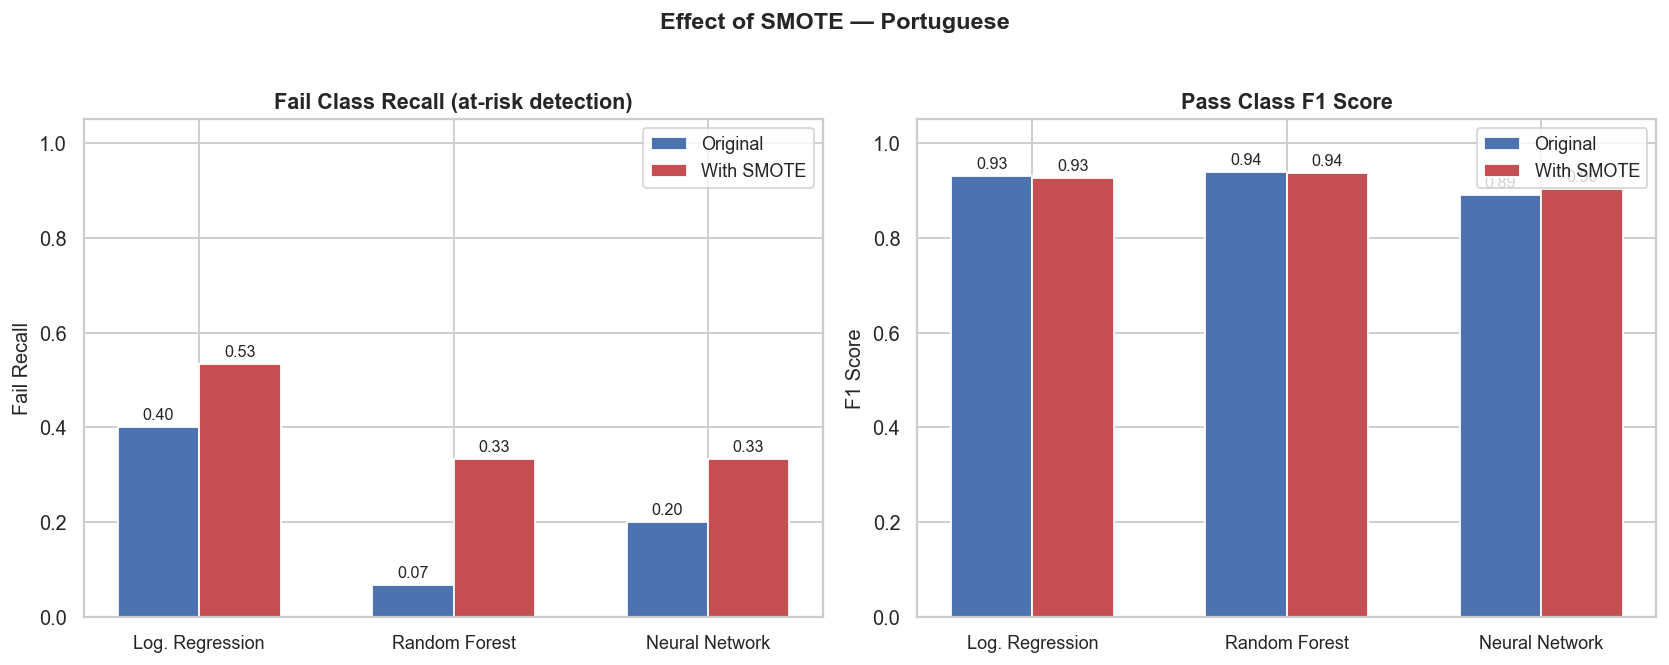

Saved: ../results/por_results_smote.csv


In [23]:
model_names = ["Log. Regression", "Random Forest", "Neural Network"]
orig_preds  = [y_pred_log, y_pred_rf, y_pred_nn]
smote_preds = [y_pred_log_sm, y_pred_rf_sm, y_pred_nn_sm]

orig_fr  = [fail_recall(y_clf_test, p) for p in orig_preds]
smote_fr = [fail_recall(y_clf_test, p) for p in smote_preds]
orig_f1  = [f1_score(y_clf_test, p, zero_division=0) for p in orig_preds]
smote_f1 = [f1_score(y_clf_test, p, zero_division=0) for p in smote_preds]

x, w = np.arange(3), 0.32
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, orig_v, smote_v, title, ylabel in [
    (axes[0], orig_fr, smote_fr, "Fail Class Recall (at-risk detection)", "Fail Recall"),
    (axes[1], orig_f1, smote_f1, "Pass Class F1 Score", "F1 Score"),
]:
    b1 = ax.bar(x-w/2, orig_v,  w, label="Original",  color="#4C72B0", edgecolor="white")
    b2 = ax.bar(x+w/2, smote_v, w, label="With SMOTE", color="#C44E52", edgecolor="white")
    for bars in [b1, b2]:
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=10)
    ax.set_ylim(0, 1.05); ax.legend(fontsize=10)

plt.suptitle("Effect of SMOTE — Portuguese", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../plots/por_plot_smote_comparison.png", bbox_inches="tight")
plt.show()

pd.DataFrame([
    {"Model": n, "Version": v,
     "Fail Recall": fail_recall(y_clf_test, p),
     "F1": f1_score(y_clf_test, p, zero_division=0),
     "Accuracy": accuracy_score(y_clf_test, p)}
    for n, orig, sm in zip(model_names, orig_preds, smote_preds)
    for v, p in [("Original", orig), ("SMOTE", sm)]
]).to_csv("../results/por_results_smote.csv", index=False)
print("Saved: ../results/por_results_smote.csv")

---
## Summary

In [24]:
print("=" * 60)
print("PORTUGUESE NOTEBOOK COMPLETE")
print("=" * 60)
print()
print("Files saved:")
print("  ../data/student_por_preprocessed.csv")
print("  ../results/por_results_correlations.csv")
print("  ../results/por_results_hypothesis_tests.csv")
print("  ../results/por_results_final_report.csv")
print("  ../results/por_results_smote.csv")
print("  ../plots/por_plot1_grade_dist_passfail.png")
print("  ../plots/por_plot3_studytime_medu.png")
print("  ../plots/por_plot5_correlation_heatmap.png")
print("  ../plots/por_plot8_confusion_matrices.png")
print("  ../plots/por_plot9_feature_importances.png")
print("  ../plots/por_plot11_roc_pr_curves.png")
print("  ../plots/por_plot_smote_comparison.png")


PORTUGUESE NOTEBOOK COMPLETE

Files saved:
  ../data/student_por_preprocessed.csv
  ../results/por_results_correlations.csv
  ../results/por_results_hypothesis_tests.csv
  ../results/por_results_final_report.csv
  ../results/por_results_smote.csv
  ../plots/por_plot1_grade_dist_passfail.png
  ../plots/por_plot3_studytime_medu.png
  ../plots/por_plot5_correlation_heatmap.png
  ../plots/por_plot8_confusion_matrices.png
  ../plots/por_plot9_feature_importances.png
  ../plots/por_plot11_roc_pr_curves.png
  ../plots/por_plot_smote_comparison.png
